# Name : Krishna Lund
# Student-ID : 023-24-0271
# Section - H
# Github : https://github.com/Krishnalund/machine-learning-practical-work
# Kaggle : https://www.kaggle.com/krishnalund18
# Dataset : House Prices - Advanced Regression Techniques
# Dataset Source : https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

# Section 1 : Problem Definition 

In [27]:
# Task-3 : In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that
# changes about how you'll evaluate the model later.

# Explanation: The goal is to predict the sale price of a house using its features, such as size, rooms, and location.
# Since the price is a continuous number, this is a regression problem.
# We cannot use accuracy, precision, or recall because the predicted price will rarely be exactly correct.
# Instead, we use MAE, MSE, RMSE, and R² to measure how close our predictions are to the actual prices.


# Section 2 : Dataset Exploration

In [28]:
# Task-1 : Load the dataset and briefly inspect it (shape, dtypes, first few rows, summary statistics).

# Explanation: The training data has 1,460 houses and 81 columns, while the test data has 1,459 houses without SalePrice.
# The data contains both numerical and categorical features. House prices range from $34,900 to $755,000 and are
# right-skewed, meaning a few expensive houses may cause larger prediction errors.


import pandas as pd
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print("Train shape:", train.shape)  
print("Test shape: ", test.shape)   

train.info()
display(train.head())
display(train['SalePrice'].describe())
display(train.describe().T)

Train shape: (1460, 81)
Test shape:  (1459, 80)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


# Section 3 : Feature and Target Identification

In [29]:
# Task-2 : Identify the dependent variable and list the independent variables, split explicitly into numerical features 
# and categorical features.

# Explanation: The dependent variable is SalePrice, which we want to predict. We selected 12 important features:
# 8 numerical and 4 categorical features. OverallQual is a 1–10 rating, but we treat it as a number 
# so the model can learn how price changes with quality.

target = 'SalePrice'
num_features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars',
                'YearBuilt', 'FullBath', 'LotArea', 'Fireplaces']
cat_features = ['Neighborhood', 'HouseStyle', 'KitchenQual', 'CentralAir']

features = num_features + cat_features
print("Dependent variable:", target)
print("Numerical (", len(num_features), "):", num_features)
print("Categorical (", len(cat_features), "):", cat_features)

Dependent variable: SalePrice
Numerical ( 8 ): ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'LotArea', 'Fireplaces']
Categorical ( 4 ): ['Neighborhood', 'HouseStyle', 'KitchenQual', 'CentralAir']


# Section 4 : Data Preparation

In [30]:
# Task-4 : Prepare X (features) and y (price) for modeling: encode every categorical column into numeric form, and briefly
# justify your choice of encoding method for each type of column.

# Explanation: 
# CentralAir: Y/N → 1/0 because there are only two categories.

# KitchenQual (ordinal Po < Fa < TA < Gd < Ex): mapped to 1–5, because the categories have a natural order
# and one column captures a "price per quality step" effect.

# Neighborhood & HouseStyle: One-hot encoding because their categories have no order. 
# drop_first=True keeps one category as the baseline.

import numpy as np
X = train[features].copy()
y = train[target]

print(X.isnull().sum())

X['CentralAir'] = X['CentralAir'].map({'Y': 1, 'N': 0})

qual_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
X['KitchenQual'] = X['KitchenQual'].map(qual_map)

X = pd.get_dummies(X, columns=['Neighborhood', 'HouseStyle'], drop_first=True, dtype=int)


GrLivArea       0
OverallQual     0
TotalBsmtSF     0
GarageCars      0
YearBuilt       0
FullBath        0
LotArea         0
Fireplaces      0
Neighborhood    0
HouseStyle      0
KitchenQual     0
CentralAir      0
dtype: int64


In [31]:
# Task-5 : Confirm X is fully numeric with no missing values.

# Explanation: After encoding, X has 41 columns, all numeric, with 0 missing values (these 12 columns have no missing values in train.csv).

print("\nAll numeric:", all(np.issubdtype(t, np.number) for t in X.dtypes))
print("Missing values:", X.isnull().sum().sum())
print("Final shape:", X.shape)      


All numeric: True
Missing values: 0
Final shape: (1460, 41)


# Section 5 : Train/Test Split

In [32]:
# Task-6 : Split X and y into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

# Explanation: Training set: 1,168 houses with 41 features, Test set: 292 houses with 41 features,
# The test data is kept separate to check how well the model works on unseen houses.
# random_state=42 makes sure we get the same split every time.


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (1168, 41) | X_test: (292, 41)
y_train: (1168,) | y_test: (292,)


# Section 6 : Linear Regression Model

In [33]:
# Task-7 : Train a LinearRegression model on the training data.

# Explanation: LinearRegression() creates the model, model.fit(X_train, y_train) trains it using the training data.
# The model learns how each feature affects the house price. It then uses these learned relationships to predict prices for new houses.

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained. Features used:", X_train.shape[1])

Model trained. Features used: 41


# Section 7 : Predictions

In [34]:
# Task-8 : Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

# Explanation: The table compares actual and predicted prices for 10 test houses. 
# The model overpredicted 6 and underpredicted 4 houses. Most predictions were reasonably close, 
# but some had larger errors, especially for lower-priced houses.

y_pred = model.predict(X_test)
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Error'] = results['Actual'] - results['Predicted']
display(results.sample(10, random_state=1).round(0))

,Actual,Predicted,Error
132,197900,206195.0,-8295.0
267,144000,159767.0,-15767.0
266,153500,162596.0,-9096.0
62,317000,320292.0,-3292.0
110,60000,43428.0,16572.0
27,141000,111341.0,29659.0
91,152000,139110.0,12890.0
189,75000,78280.0,-3280.0
85,133000,139002.0,-6002.0
164,118500,108169.0,10331.0


# Section 8 : Coefficients and Intercept

In [35]:
# Task-9 :  Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line,
# plain-English interpretation for each feature (e.g. "each additional bathroom is associated with a price increase
# of approximately ___, holding other features constant").

print("Intercept:", round(model.intercept_, 2))

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})

baseline_nbhd  = sorted(train['Neighborhood'].unique())[0]
baseline_style = sorted(train['HouseStyle'].unique())[0]

unit_text = {
    'GrLivArea':   'each additional square foot of living area',
    'OverallQual': 'each 1-point increase in overall quality (1–10 scale)',
    'TotalBsmtSF': 'each additional square foot of basement',
    'GarageCars':  'each additional car of garage capacity',
    'YearBuilt':   'each year newer the house was built',
    'FullBath':    'each additional full bathroom',
    'LotArea':     'each additional square foot of lot',
    'Fireplaces':  'each additional fireplace',
    'CentralAir':  'having central air (vs. not)',
    'KitchenQual': 'each one-step improvement in kitchen quality (Po=1 … Ex=5)',
}

def interpret(feat, c):
    d = 'increase' if c > 0 else 'decrease'
    amt = f"${abs(c):,.2f}" if abs(c) < 10 else f"${abs(c):,.0f}"
    if feat.startswith('Neighborhood_'):
        return (f"Compared with {baseline_nbhd}, a house in {feat.split('_',1)[1]} "
                f"is associated with a price {d} of ~{amt}, other features constant.")
    if feat.startswith('HouseStyle_'):
        return (f"Compared with style {baseline_style}, style {feat.split('_',1)[1]} "
                f"is associated with a price {d} of ~{amt}, other features constant.")
    text = unit_text[feat]
    return f"{text[0].upper() + text[1:]} is associated with a price {d} of ~{amt}, holding other features constant."
coef_df['Interpretation'] = [interpret(f, c) for f, c in zip(coef_df.Feature, coef_df.Coefficient)]
pd.set_option('display.max_colwidth', None)
display(coef_df.round(2))

Intercept: -562089.87


,Feature,Coefficient,Interpretation
0,GrLivArea,54.13,"Each additional square foot of living area is associated with a price increase of ~$54, holding other features constant."
1,OverallQual,13415.37,"Each 1-point increase in overall quality (1–10 scale) is associated with a price increase of ~$13,415, holding other features constant."
2,TotalBsmtSF,4.23,"Each additional square foot of basement is associated with a price increase of ~$4.23, holding other features constant."
3,GarageCars,10187.11,"Each additional car of garage capacity is associated with a price increase of ~$10,187, holding other features constant."
4,YearBuilt,233.28,"Each year newer the house was built is associated with a price increase of ~$233, holding other features constant."
5,FullBath,-1556.94,"Each additional full bathroom is associated with a price decrease of ~$1,557, holding other features constant."
6,LotArea,0.53,"Each additional square foot of lot is associated with a price increase of ~$0.53, holding other features constant."
7,Fireplaces,6407.88,"Each additional fireplace is associated with a price increase of ~$6,408, holding other features constant."
8,KitchenQual,14532.94,"Each one-step improvement in kitchen quality (Po=1 … Ex=5) is associated with a price increase of ~$14,533, holding other features constant."
9,CentralAir,5651.62,"Having central air (vs. not) is associated with a price increase of ~$5,652, holding other features constant."


In [36]:
# Explanation: 
# Each coefficient shows how the predicted house price changes when that feature increases by 1 unit, while other features stay the same.
# Living area, OverallQual, KitchenQual, garage space, and fireplaces have positive effects on price.
# FullBath has a small negative coefficient, likely because it overlaps with other features such as size and quality (multicollinearity).
# Neighborhood has the largest differences, with some areas adding much more value than others compared with the baseline.
# Overall, location, quality, living area, and garage capacity have the strongest effects on predicted price.

In [37]:
# Task -10  Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

# Explanation : No. The intercept is -$562,090, which represents the predicted price when all features are 0. 
# Such a house cannot exist, so the value is not meaningful.
# The large negative value mainly comes from features like YearBuilt, which have realistic values far from 0. 
# Therefore, the intercept is mainly a mathematical value used by the model, not an actual house price.

# Section 9 : Residual Analysis

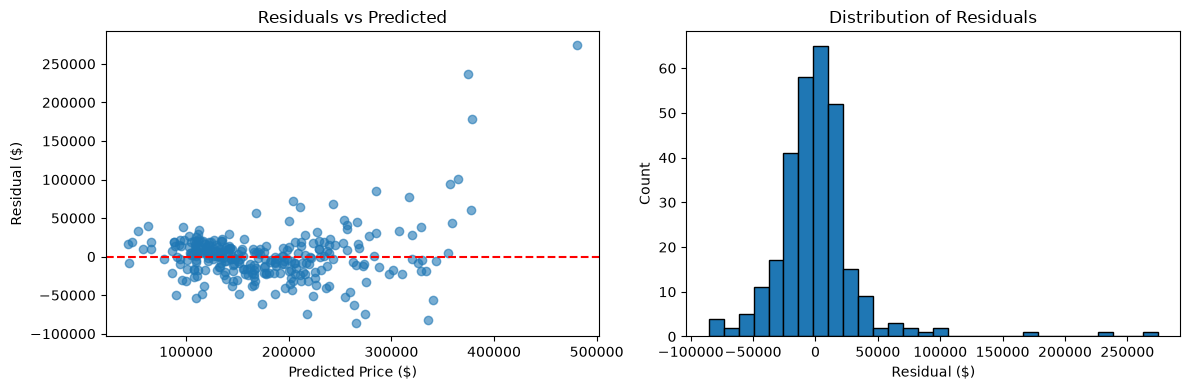

Mean residual: 1463.07


In [38]:
# Task-11 :  Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of
# residuals). Do the residuals look randomly scattered, or is there a visible pattern?

# Explanation: The mean residual is about $1,463, so the model has very little overall bias.
# For most houses, residuals are scattered around zero, meaning predictions are reasonably balanced.
# For expensive houses, the errors become larger and mostly positive, showing underprediction.
# The histogram is centered near zero but has a right tail because of some large errors.
# Overall, the residuals are not completely random; the model is less accurate for expensive houses.

import matplotlib.pyplot as plt
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y_pred, residuals, alpha=0.6)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Predicted Price ($)'); ax[0].set_ylabel('Residual ($)')
ax[0].set_title('Residuals vs Predicted')

ax[1].hist(residuals, bins=30, edgecolor='black')
ax[1].set_xlabel('Residual ($)'); ax[1].set_ylabel('Count')
ax[1].set_title('Distribution of Residuals')
plt.tight_layout(); plt.show()

print("Mean residual:", residuals.mean().round(2))

# Section 10 : Regression Metrics

In [39]:
# Task-12 : Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.

# Explanation: MAE = $21,413: Predictions are off by about $21,400 on average.
# RMSE = $35,319: Larger errors increase this value, showing some big prediction mistakes.
# MSE = 1.247 × 10⁹: Squared error; mainly useful for calculations and model training.
# R² = 0.8374: The model explains about 83.7% of the variation in house prices.
# Overall: The model is a good baseline but struggles with some expensive houses.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

metrics_test = pd.DataFrame({'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
                             'Test Value': [mae, mse, rmse, r2]})
display(metrics_test.style.format({'Test Value': '{:,.4f}'}).hide(axis='index'))

Metric,Test Value
MAE,"21,413.3242"
MSE,"1,247,410,540.2469"
RMSE,"35,318.6996"
R²,0.8374


In [40]:
# Task-13 : In your own words, what does each metric tell you, and which one would you show to a non-technical
# stakeholder? Why?

# Explanation: 
# MAE: Average error in dollars; easiest to understand.
# MSE: Squared error, so it is harder to interpret.
# RMSE: Shows error in dollars but gives more importance to large errors.
# R²: Shows how much price variation the model explains.
# For a stakeholder, I would use MAE: “The model's predictions are off by about $21,400 on average.”

# Section 11 : Training vs Testing Performance

In [41]:
# Task-14 : Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Part 5 test-set
# metrics in one comparison table.

# Explanation: The training and testing results are quite similar, which shows that the model performs consistently on both datasets.
# The test MAE and RMSE are slightly higher than the training values, which is normal because the test data is unseen by the model. 
# The test R² is slightly higher than the training R² because the test house prices have more variation.
# Overall, the small difference between training and testing results suggests that the model generalizes reasonably well 
# and does not show a major overfitting problem.

train_pred = model.predict(X_train)
test_pred  = y_pred

def all_metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)
    return [mean_absolute_error(y_true, y_hat), mse, np.sqrt(mse), r2_score(y_true, y_hat)]

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Training': all_metrics(y_train, train_pred),
    'Testing':  all_metrics(y_test,  test_pred)
})
display(comparison.style.format({'Training': '{:,.4f}', 'Testing': '{:,.4f}'}).hide(axis='index'))

Metric,Training,Testing
MAE,"20,552.3949","21,413.3242"
MSE,"1,062,841,788.6177","1,247,410,540.2469"
RMSE,"32,601.2544","35,318.6996"
R²,0.8218,0.8374


In [42]:
# Task-15 :  Is there a large gap between training and testing performance? What would a large gap suggest about
# overfitting or generalization, and what does your actual result suggest here?

# Explanation: The training and testing results are quite close, so there is no strong sign of overfitting. 
# The model performs similarly on both datasets, which means it generalizes reasonably well to unseen data. 
# The test errors are only slightly higher than the training errors, which is normal.
# However, the model may have some underfitting because Linear Regression is a simple model and may not 
# capture complex relationships between house features and prices. This could be improved by adding useful features,
# using transformations, or trying more advanced models.


# Section 12 : Model Interpretation

In [43]:
# Task-16 : Looking back at your Part 4 coefficient table, which 2–3 features appear most influential on price? Justify your
# answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more
# important feature if the underlying scales differ — discuss this briefly).

# Explanation: The raw coefficients are not directly fair to compare because the features use different units.
# For example, GrLivArea has a small coefficient of $54 per square foot, while neighborhood features have much 
# larger coefficients because they are 0/1 variables. After considering the standard deviation of each feature, 
# GrLivArea is the most influential feature, followed by OverallQual and Neighborhood. A typical change in living 
# area (about 524 sq ft) changes the predicted price by about $28,400, while a typical change in OverallQual changes
# it by about $18,300. Neighborhood also has a strong influence, showing that location is an important factor in house prices. 
# Therefore, the three most influential factors are living area, overall quality, and neighborhood. These results show association, 
# not that changing one feature will definitely cause the same change in price.

coef_df['Std_Effect'] = coef_df['Coefficient'] * X_train.std().values
top = coef_df.reindex(coef_df['Std_Effect'].abs().sort_values(ascending=False).index)
display(top[['Feature', 'Coefficient', 'Std_Effect']].head(10).round(2))

,Feature,Coefficient,Std_Effect
0,GrLivArea,54.13,28389.00
1,OverallQual,13415.37,18347.11
25,Neighborhood_NridgHt,70041.21,15589.62
24,Neighborhood_NoRidge,75005.88,12433.50
8,KitchenQual,14532.94,9606.82
31,Neighborhood_StoneBr,73102.03,9487.65
15,Neighborhood_Crawfor,45870.16,8737.41
30,Neighborhood_Somerst,34856.98,8221.60
14,Neighborhood_CollgCr,25663.89,7649.42
3,GarageCars,10187.11,7540.10


In [44]:
# Task-17 Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices?
# Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear
# Regression have for this dataset? What would you try next?

# Explanation: The model predicts house prices reasonably well, explaining about 83.7% of the variation in unseen test data
# (R² = 0.837). Its average error (MAE) is about $21,400, roughly 12% of the average house price, and training and test results
# are close, so there is no major overfitting. MAE is the most useful metric here because it is in dollars, easy to explain, 
# and not dominated by a few large mistakes, while RMSE and R² are better for comparing models. GrLivArea has the strongest 
# effect once feature scales are accounted for, followed by OverallQual and Neighborhood. Linear Regression cannot capture 
# non-linear relationships, and the residuals show larger errors for expensive houses. It also uses only 12 features and is 
# affected by correlated features and outliers. Next I would add more useful features, log-transform SalePrice, and try 
# Random Forest or Gradient Boosting.


# Section 13 : Conclusion

In [45]:
# Task-18 Apply the same feature selection and encoding you used on train.csv to test.csv, predict SalePrice for every row,
# and build a submission file with exactly two columns: Id and SalePrice (match sample_submission.csv's format).
# Save it as submission.csv.

# Explanation: I applied the same feature selection, missing-value handling, and encoding used for the training data to test.csv. 
# The test data was aligned with the training data, giving 1,459 rows and 41 features with no missing values.
# For the final prediction, I retrained Linear Regression using all 1,460 training houses and predicted the SalePrice 
# for all test houses. The predictions were saved in submission.csv, which contains exactly two columns: Id and SalePrice,
# matching the required submission format. Seven predictions were below the minimum training price of $34,900, 
# so they were clipped to this value. These houses were generally small, old, and had low quality ratings. 
# This shows a limitation of Linear Regression: because it uses a straight-line relationship, 
# it can produce unrealistic predictions at extreme values.

Xt = test[features].copy()
Xt['TotalBsmtSF'] = Xt['TotalBsmtSF'].fillna(train['TotalBsmtSF'].median())
Xt['GarageCars']  = Xt['GarageCars'].fillna(train['GarageCars'].median())
Xt['KitchenQual'] = Xt['KitchenQual'].fillna(train['KitchenQual'].mode()[0])

Xt['CentralAir']  = Xt['CentralAir'].map({'Y': 1, 'N': 0})
Xt['KitchenQual'] = Xt['KitchenQual'].map(qual_map)

Xt = pd.get_dummies(Xt, columns=['Neighborhood', 'HouseStyle'], dtype=int)
Xt = Xt.reindex(columns=X.columns, fill_value=0)

assert Xt.isnull().sum().sum() == 0
print("Test features shape:", Xt.shape)          

final_model = LinearRegression().fit(X, y)
test_pred = final_model.predict(Xt)

test_pred = np.clip(test_pred, y.min(), None)

submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': test_pred})
submission.to_csv('submission.csv', index=False)

print(submission.shape)                             
print(list(submission.columns))                    
display(submission.head())


Test features shape: (1459, 41)
(1459, 2)
['Id', 'SalePrice']


,Id,SalePrice
0,1461,109595.523885
1,1462,166960.601949
2,1463,160704.117429
3,1464,185965.251212
4,1465,258405.434375


In [46]:
# Explanation: This cell checks submission.csv against Kaggle's sample_submission.csv. 
# It has the same columns (Id, SalePrice), the same 1,459 rows, the same Ids in the same order, 
# and no missing values, so the file is in a valid format. Seven predictions were clipped at $34,900.

sample = pd.read_csv('sample_submission.csv')
sub = pd.read_csv('submission.csv')

print("Same columns:", list(sub.columns) == list(sample.columns))
print("Same row count:", len(sub) == len(sample))
print("Same Ids, same order:", (sub['Id'] == sample['Id']).all())
print("Any NaN:", sub.isnull().any().any())
print("Min / Max prediction:", round(sub['SalePrice'].min()), round(sub['SalePrice'].max()))
print("Predictions clipped:", (final_model.predict(Xt) < y.min()).sum())

Same columns: True
Same row count: True
Same Ids, same order: True
Any NaN: False
Min / Max prediction: 34900 525122
Predictions clipped: 7


In [47]:
# Explanation: These are the 7 houses whose raw predictions fell below the minimum training price ($34,900). 
# All are small (407–733 sq ft), old (built 1900–1952) and low quality (OverallQual 1–4), where the straight-line
# model extrapolates too low. The lowest raw prediction was $16,087 and none were zero or negative, so clipping 
# to $34,900 is safe.

raw = final_model.predict(Xt)
print("Lowest raw prediction:", round(raw.min()))
print("Zero or negative:", (raw <= 0).sum())

mask = raw < y.min()
display(test.loc[mask, ['Id', 'GrLivArea', 'OverallQual', 'YearBuilt', 'Neighborhood']]
        .assign(Raw_Pred=raw[mask].round(0))
        .set_index('Id'))

Lowest raw prediction: 16087
Zero or negative: 0


,GrLivArea,OverallQual,YearBuilt,Neighborhood,Raw_Pred
Id,,,,,
1815,612,2,1940,OldTown,26950.0
1848,660,2,1947,Sawyer,16087.0
2099,407,2,1946,OldTown,21143.0
2217,733,1,1952,IDOTRR,28625.0
2400,670,3,1945,BrkSide,26770.0
2758,720,4,1900,OldTown,32442.0
2872,498,2,1922,Edwards,24538.0


In [ ]:
# Task-19: Submit submission.csv on the competition's "Submit Predictions" page. Record your public leaderboard score
# and rank, and write 1–2 sentences on how it felt to see your model measured against thousands of other real submissions.

# I submitted submission.csv (1,459 rows, columns Id and SalePrice) to the House Prices - Advanced Regression Techniques competition on Kaggle.
# Public leaderboard score: 0.16772
# Public leaderboard rank: 2747

# Seeing my model ranked at 2747 among thousands of real submissions showed me that a simple Linear Regression on 12 hand-picked features is a 
# reasonable baseline but far from the top models. Those use many more features, log-transformed prices and stronger algorithms 
# such as gradient boosting, which are the same improvements I listed in my conclusion.